# Empirical vs. Simulated Comparison

Single-ROI time series (Blue / light-Blue dashed vs. Red / light-Red dashed) plus square plots of FC, FCD, phFCD, metastability, amplitude and omega.

In [1]:
from pathlib import Path
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt

project_root = Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.dataset import load_mat_data, fft_bandpass_3d, hilbert_transform
from src.models import CoupledHopfModel
from src.metrics import compute_static_fc
from src.metrics.dynamics_metrics import fcd_matrix, phfcd_matrix

def _to_numpy(x):
    return x.detach().cpu().numpy() if isinstance(x, torch.Tensor) else np.asarray(x)

plt.rcParams['figure.dpi'] = 140
%matplotlib inline

In [2]:
dataset_path = project_root / 'data' / 'ts_young' / 'ts_young_TR0.72.mat'
subject_index = 0
focus_roi = 25
dt = 0.72
f_lo, f_hi = 0.008, 0.08
v_lim = 2.5
show_timepoints = 200       # how many points to show in the time-series panels
n_total = 1200              # total points used for FC / FCD / phFCD
sq = 2.0                    # size of every (square) figure in inches
fontsize = 20

out_base = project_root / 'paper'
for sub in ['images/comparison', 'images_png/comparison', 'images_svg/comparison']:
    (out_base / sub).mkdir(parents=True, exist_ok=True)

def save(fig, name):
    fig.savefig(out_base / 'images' / 'comparison' / f'{name}.svg', dpi=200, bbox_inches='tight')
    fig.savefig(out_base / 'images_png' / 'comparison' / f'{name}.png', dpi=200, bbox_inches='tight')
    fig.savefig(out_base / 'images_svg' / 'comparison' / f'{name}.svg', bbox_inches='tight')

data = load_mat_data(str(dataset_path))
raw = data['timeseries_all'].transpose(2, 0, 1)    # (subjects, rois, T)
print('shape:', raw.shape)

shape: (94, 100, 1200)


In [3]:
# --- Empirical: normalize, bandpass, Hilbert ---
ts = torch.as_tensor(raw)
subject_ts = ts[subject_index : subject_index + 1]
mean = subject_ts.mean(dim=2, keepdim=True)
std = subject_ts.std(dim=2, keepdim=True) + 1e-8
normalized = (subject_ts - mean) / std
filtered = fft_bandpass_3d(normalized, dt=dt, f_lo=f_lo, f_hi=f_hi)
analytic_emp_t = hilbert_transform(filtered)[0, :, :n_total]  # (N, T) complex
analytic_emp = _to_numpy(analytic_emp_t)
n_rois = analytic_emp.shape[0]
time_full = np.arange(n_total, dtype=np.float32) * dt
time = time_full[:show_timepoints]
print('empirical analytic:', analytic_emp.shape)

empirical analytic: (100, 1200)


In [4]:
# --- Simulation: Coupled Hopf, initialised from the empirical initial state ---
torch.manual_seed(0)
model = CoupledHopfModel(
    n_rois=n_rois,
    initial_a=-0.02,
    initial_g=1.0,
    initial_kappa=0.1,
    noise_sigma=0.1,
)
with torch.no_grad():
    sim = model.forward(initial_state=analytic_emp_t[None, :, 0], n_steps=n_total)
analytic_sim = _to_numpy(sim[0])  # (N, T) complex
print('simulated analytic:', analytic_sim.shape)

simulated analytic: (100, 1200)


## 1. Time series (single ROI)

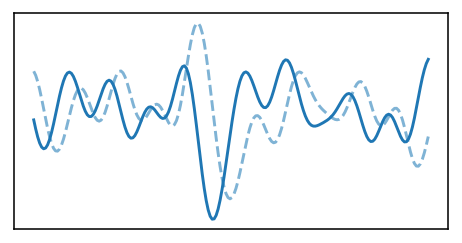

In [5]:
# Empirical: Blue (real) + light Blue dashed (imag)
emp_real_color = '#1f77b4'
emp_imag_color = '#7fb3d5'

fig, ax = plt.subplots(figsize=(2*sq, sq))
fig.patch.set_alpha(0.0)
ax.plot(time, analytic_emp[focus_roi, :show_timepoints].imag, color=emp_imag_color, linestyle='--', label='Imag')
ax.plot(time, analytic_emp[focus_roi, :show_timepoints].real, color=emp_real_color, label='Real')
ax.set_yticklabels([]); ax.set_xticklabels([]); ax.set_xticks([]); ax.set_yticks([])
#ax.set_ylim(-v_lim, v_lim); 
#ax.set_title('Empirical', fontdict={'color': emp_real_color, 'size': 14})
save(fig, 'empirical_timeseries')
plt.show()

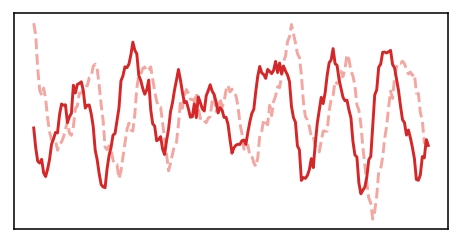

In [6]:
# Simulated: Red (real) + light Red dashed (imag)
sim_real_color = '#d62728'
sim_imag_color = '#f4a6a0'

fig, ax = plt.subplots(figsize=(2*sq, sq))
fig.patch.set_alpha(0.0)
ax.plot(time, analytic_sim[focus_roi, :show_timepoints].imag, color=sim_imag_color, linestyle='--', label='Imag')
ax.plot(time, analytic_sim[focus_roi, :show_timepoints].real, color=sim_real_color, label='Real')
ax.set_yticklabels([]); ax.set_xticklabels([]); ax.set_xticks([]); ax.set_yticks([])
#ax.set_ylim(-v_lim, v_lim); 
#ax.set_title('Simulated', fontdict={'color': sim_real_color, 'size': 14})
save(fig, 'simulated_timeseries')
plt.show()

## 2. FC / FCD / phFCD

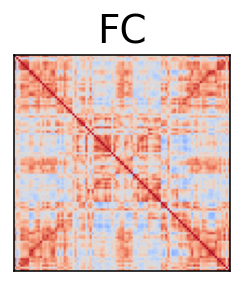

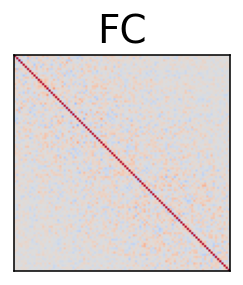

In [7]:
def plot_lower_tri(mat, cmap, title, vmin, vmax, fname):
    n = mat.shape[0]
    mask = np.triu(np.ones((n, n), dtype=bool), k=1)
    masked = np.where(mask, np.nan, mat)
    fig, ax = plt.subplots(figsize=(sq, sq))
    fig.patch.set_alpha(0.0)
    im = ax.imshow(mat, vmin=vmin, vmax=vmax, cmap=cmap)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontdict={'size': fontsize})
    ax.set_box_aspect(1)
    save(fig, fname)
    plt.show()
    return im

# FC — coolwarm, [-1, 1]
fc_emp = _to_numpy(compute_static_fc(torch.tensor(analytic_emp))[0])
fc_sim = _to_numpy(compute_static_fc(torch.tensor(analytic_sim))[0])
plot_lower_tri(fc_emp, 'coolwarm', 'FC', -1, 1, 'fc_empirical')
plot_lower_tri(fc_sim, 'coolwarm', 'FC', -1, 1, 'fc_simulated')

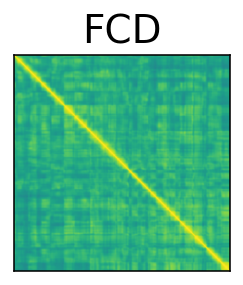

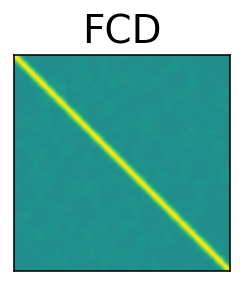

In [8]:
# FCD — different palette (viridis), computed on real part, transposed to (T, N)
win_len = int(round(30.0 / dt))
win_step = int(round(2.0 / dt))
fcd_emp = _to_numpy(fcd_matrix(torch.tensor(analytic_emp.real).T, win_len, win_step))
fcd_sim = _to_numpy(fcd_matrix(torch.tensor(analytic_sim.real).T, win_len, win_step))
plot_lower_tri(fcd_emp, 'viridis', 'FCD', -1, 1, 'fcd_empirical')
plot_lower_tri(fcd_sim, 'viridis', 'FCD', -1, 1, 'fcd_simulated')

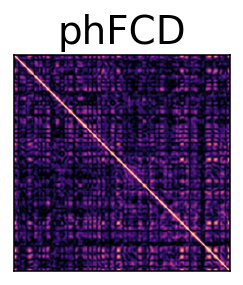

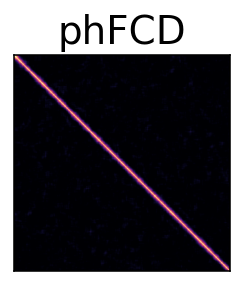

In [9]:
# phFCD — magma palette like fc_phfcd_comparison.pdf
phases_emp = torch.angle(torch.tensor(analytic_emp)).T  # (T, N)
phases_sim = torch.angle(torch.tensor(analytic_sim)).T
phfcd_emp = _to_numpy(phfcd_matrix(phases_emp))
phfcd_sim = _to_numpy(phfcd_matrix(phases_sim))
plot_lower_tri(phfcd_emp, 'magma', 'phFCD', 0, 1, 'phfcd_empirical')
plot_lower_tri(phfcd_sim, 'magma', 'phFCD', 0, 1, 'phfcd_simulated')

## 3. Metastability, Amplitude, Omega (1 curve each)

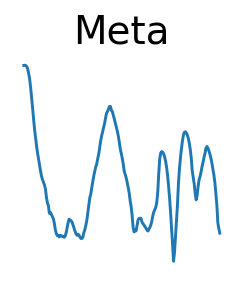

In [10]:
# Metastability: Kuramoto order parameter R(t) — 1 curve (empirical)
R_emp = np.abs(np.exp(1j * np.angle(analytic_emp[:, :show_timepoints])).mean(axis=0))
fig, ax = plt.subplots(figsize=(sq, sq))
fig.patch.set_alpha(0.0)
ax.plot(time, R_emp[:show_timepoints], color=emp_real_color)
ax.set_yticklabels([]); ax.set_xticklabels([]); ax.set_xticks([]); ax.set_yticks([])
#ax.set_xlabel('Time ($s$)'); ax.set_ylabel('$R(t)$')
#ax.set_ylim(0, 1)
ax.set_title(f'Meta', fontdict={'size': fontsize})
ax.set_box_aspect(1)
ax.axis('off')
save(fig, 'metastability')
plt.show()

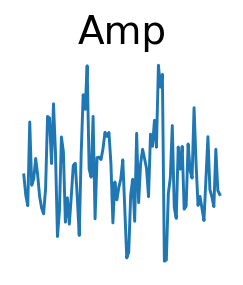

In [11]:
# Amplitude per ROI — 1 curve (empirical mean |z|)
amp_emp = np.abs(analytic_emp[:, :show_timepoints]).mean(axis=1)
fig, ax = plt.subplots(figsize=(sq, sq))
fig.patch.set_alpha(0.0)
ax.plot(np.arange(1, n_rois + 1), amp_emp, color=emp_real_color)
ax.set_yticklabels([]); ax.set_xticklabels([]); ax.set_xticks([]); ax.set_yticks([])
#ax.set_xlabel('ROI'); ax.set_ylabel(r'$\langle |z| \rangle$')
ax.set_title('Amp', fontdict={'size': fontsize})
ax.set_box_aspect(1)
ax.axis('off')
save(fig, 'amplitude')
plt.show()

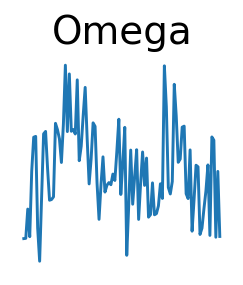

In [12]:
# Omega per ROI — 1 curve, mean instantaneous angular frequency
phase_unwrap = np.unwrap(np.angle(analytic_emp[:, :show_timepoints]), axis=1)
dphi = np.diff(phase_unwrap, axis=1)
dphi = dphi - 2.0 * np.pi * np.round(dphi / (2.0 * np.pi))
omega_emp = (dphi / dt).mean(axis=1)
fig, ax = plt.subplots(figsize=(sq, sq))
fig.patch.set_alpha(0.0)
ax.plot(np.arange(1, n_rois + 1), omega_emp, color=emp_real_color)
ax.set_yticklabels([]); ax.set_xticklabels([]); ax.set_xticks([]); ax.set_yticks([])
#ax.set_xlabel('ROI'); ax.set_ylabel(r'$\omega$ (rad/s)')
ax.set_title('Omega', fontdict={'size': fontsize})
ax.set_box_aspect(1)
ax.axis('off')
save(fig, 'omega')
plt.show()

## 4. Old vs New: Hopf grid search vs gradient descent

Bar-plot comparison of Coupled Hopf trained with grid search (grey) vs gradient descent with composite loss (orange), on the HCP and LSD datasets. Values are read from `paper/sections/ts_young_model_table.tex` and `paper/sections/lsd_model_table.tex`. KS distances and the metastability absolute error are converted to higher-is-better scores via `score = 1 - value`.

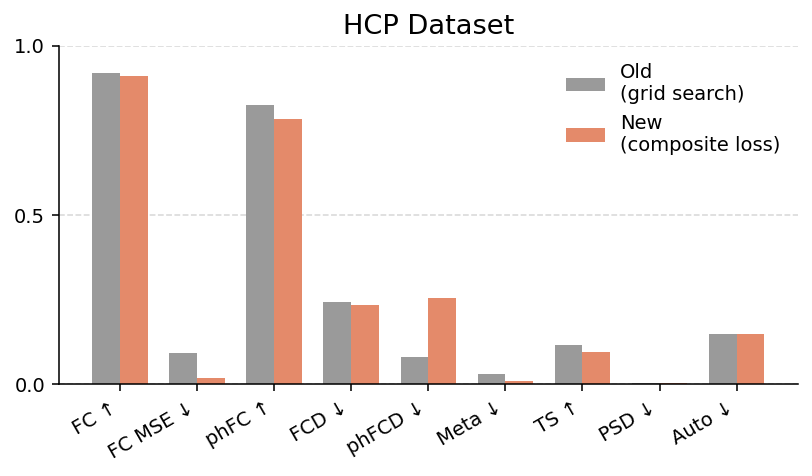

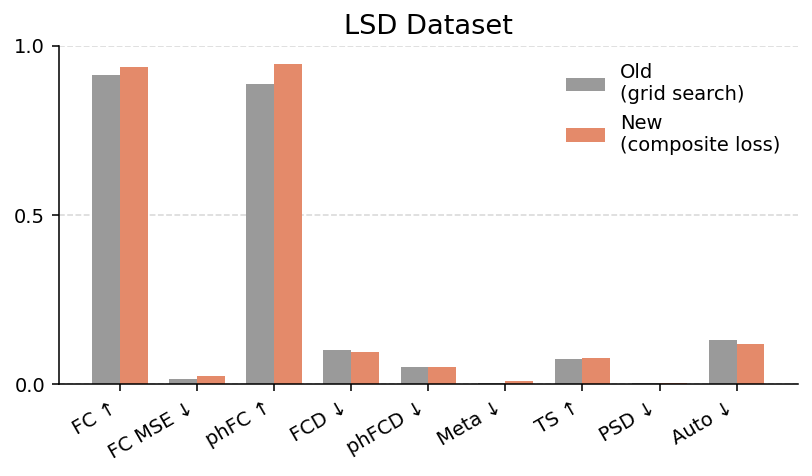

In [27]:
# Every metric from paper/sections/{ts_young,lsd}_model_table.tex.
# Arrow in the label shows the native direction:
#   ↑ = higher is better (kept as-is for the score)
#   ↓ = lower is better  (converted to 1 - value so all bars share a 0-1 axis)
# Toggle metrics by commenting out rows in METRICS.

#             label,        key,        higher_is_better
METRICS = [
    ('FC ↑',     'FC',       True),
    ('FC MSE ↓', 'FC_MSE',   False),
    ('phFC ↑',   'phFC',     True),
    ('FCD ↓',    'FCD',      False),
    ('phFCD ↓',  'phFCD',    False),
    ('Meta ↓',   'Meta',     False),
    ('TS ↑',     'TS',       True),
    ('PSD ↓',    'PSD',      False),
    ('Auto ↓',   'Autocorr', False),
]

# HCP (ts_young_model_table.tex)
hcp_old_raw = {'FC': 0.919, 'FC_MSE': 0.093, 'phFC': 0.825, 'FCD': 0.242,
               'phFCD': 0.082, 'Meta': 0.030, 'TS': 0.116, 'PSD': 0.004, 'Autocorr': 0.150}
hcp_new_raw = {'FC': 0.911, 'FC_MSE': 0.018, 'phFC': 0.783, 'FCD': 0.235,
               'phFCD': 0.254, 'Meta': 0.0095, 'TS': 0.097, 'PSD': 0.004, 'Autocorr': 0.148}

# LSD (lsd_model_table.tex)
lsd_old_raw = {'FC': 0.913, 'FC_MSE': 0.016, 'phFC': 0.887, 'FCD': 0.101,
               'phFCD': 0.050, 'Meta': 0.004, 'TS': 0.074, 'PSD': 0.004, 'Autocorr': 0.132}
lsd_new_raw = {'FC': 0.937, 'FC_MSE': 0.026, 'phFC': 0.945, 'FCD': 0.095,
               'phFCD': 0.050, 'Meta': 0.011, 'TS': 0.077, 'PSD': 0.004, 'Autocorr': 0.118}

def to_scores(raw):
    return [raw[key] if higher else raw[key] for _, key, higher in METRICS]

old_color = '#9a9a9a'   # grey (grid search)
new_color = '#e48a6a'   # orange (composite loss)

def plot_old_vs_new(ax, old_scores, new_scores, title):
    labels = [label for label, _, _ in METRICS]
    x = np.arange(len(labels))
    width = 0.36
    ax.bar(x - width/2, old_scores, width, color=old_color, edgecolor='none',
           label='Old\n(grid search)')
    ax.bar(x + width/2, new_scores, width, color=new_color, edgecolor='none',
           label='New\n(composite loss)')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10, rotation=30, ha='right')
    ax.set_ylim(0, 1.0)
    ax.set_yticks([0.0, 0.5, 1.0])
    #ax.set_ylabel('Score', fontsize=11)
    ax.set_title(title, fontsize=14)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)

fig_w = max(4.0, 0.6 * len(METRICS) + 0.5)

# --------------------------
# Plot 1: HCP
# --------------------------
fig_hcp, ax_hcp = plt.subplots(figsize=(fig_w, 3.5))
fig_hcp.patch.set_alpha(0.0)
plot_old_vs_new(ax_hcp, to_scores(hcp_old_raw), to_scores(hcp_new_raw), 'HCP Dataset')
ax_hcp.legend(loc='upper right', bbox_to_anchor=(1.0, 1.0), frameon=False, fontsize=10)
plt.tight_layout()
save(fig_hcp, 'hcp_old_vs_new_hopf')

# --------------------------
# Plot 2: LSD
# --------------------------
fig_lsd, ax_lsd = plt.subplots(figsize=(fig_w, 3.5))
fig_lsd.patch.set_alpha(0.0)
plot_old_vs_new(ax_lsd, to_scores(lsd_old_raw), to_scores(lsd_new_raw), 'LSD Dataset')
ax_lsd.legend(loc='upper right', bbox_to_anchor=(1.0, 1.0), frameon=False, fontsize=10)
plt.tight_layout()
save(fig_lsd, 'lsd_old_vs_new_hopf')
plt.show()

## 5. Hopf grid-search landscape (FC similarity)

Notebook-friendly version of `examples/plot_grid_search_fc_similarity.py`: a 2D slice over `(initial_g, initial_a)`, reducing over `initial_kappa` by keeping the best FC correlation per cell from `results/grid_search/grid_search_results.json`.

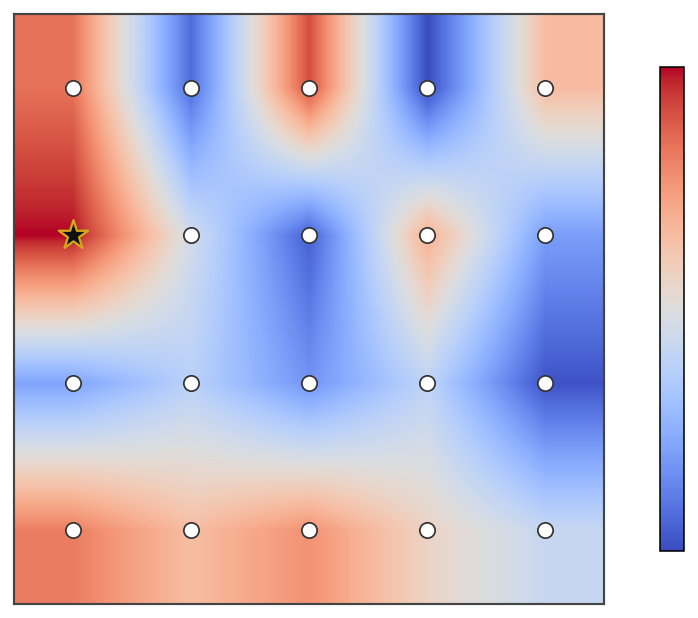

In [ ]:
import json
import math
from matplotlib.patches import Circle

grid_results_path = project_root / 'results' / 'grid_search' / 'grid_search_results.json'

X_PARAM, Y_PARAM, REDUCE_PARAM = 'initial_g', 'initial_a', 'initial_kappa'
METRIC, METRIC_LABEL, HIGHER_IS_BETTER = 'fc_correlation', 'FC similarity', True


def format_param(value):
    value = float(value)
    if math.isclose(value, round(value), abs_tol=1e-9):
        return str(int(round(value)))
    if abs(value) < 0.005:
        return '0'
    return f'{value:.2f}'.rstrip('0').rstrip('.')


def build_metric_surface(results, *, x_param, y_param, reduce_param, metric, higher_is_better):
    x_values = sorted({float(entry['params'][x_param]) for entry in results})
    y_values = sorted({float(entry['params'][y_param]) for entry in results})
    chooser = max if higher_is_better else min

    def metric_value(entry):
        return float(entry['metrics'][metric])

    surface = np.full((len(y_values), len(x_values)), np.nan, dtype=float)
    reduced_values = {}

    for y_index, y_value in enumerate(y_values):
        for x_index, x_value in enumerate(x_values):
            candidates = [
                entry
                for entry in results
                if math.isclose(float(entry['params'][x_param]), x_value)
                and math.isclose(float(entry['params'][y_param]), y_value)
            ]
            if not candidates:
                continue
            best_cell = chooser(candidates, key=metric_value)
            surface[y_index, x_index] = metric_value(best_cell)
            if reduce_param in best_cell['params']:
                reduced_values[(x_index, y_index)] = float(best_cell['params'][reduce_param])

    best_entry = chooser(results, key=metric_value)
    return x_values, y_values, surface, reduced_values, best_entry


def plot_grid_search_landscape(
    *,
    x_values,
    y_values,
    surface,
    reduced_values,
    best_entry,
    metric,
    metric_label,
    x_param,
    y_param,
    reduce_param,
):
    fig, ax = plt.subplots(figsize=(6.0, 5.0))
    fig.patch.set_alpha(0.0)
    fig.subplots_adjust(left=0.22, right=0.83, top=0.80, bottom=0.18)

    image = ax.imshow(
        surface,
        origin='lower',
        cmap='coolwarm',
        interpolation='bilinear',
        extent=(-0.5, len(x_values) - 0.5, -0.5, len(y_values) - 0.5),
        vmin=float(np.nanmin(surface)),
        vmax=float(np.nanmax(surface)),
        aspect='auto',
    )
    ax.set_box_aspect(1)

    # ax.set_xticks(range(len(x_values)))
    #ax.set_xticklabels([format_param(value) for value in x_values], fontsize=11)
    #ax.tick_params(axis='x', top=True, labeltop=True, bottom=False, labelbottom=False, pad=6)
    #ax.xaxis.set_label_position('top')

    #ax.set_yticks(range(len(y_values)))
    #ax.set_yticklabels([format_param(value) for value in y_values], fontsize=11)
    #ax.tick_params(axis='y', pad=6)
    ax.set_xticks([]); ax.set_yticks([])

    ax.set_xlim(-0.5, len(x_values) - 0.5)
    ax.set_ylim(-0.5, len(y_values) - 0.5)
    ax.grid(color='white', linewidth=0.9, alpha=0.18)

    for spine in ax.spines.values():
        spine.set_linewidth(1.1)
        spine.set_color('#444444')

    x_grid, y_grid = np.meshgrid(range(len(x_values)), range(len(y_values)))
    ax.scatter(
        x_grid.flatten(),
        y_grid.flatten(),
        s=62,
        facecolor='white',
        edgecolor='#333333',
        linewidth=0.9,
        zorder=3,
    )

    best_x = x_values.index(float(best_entry['params'][x_param]))
    best_y = y_values.index(float(best_entry['params'][y_param]))
    ax.scatter(
        [best_x],
        [best_y],
        marker='*',
        s=250,
        facecolor='#111111',
        edgecolor='#d4a61f',
        linewidth=1.2,
        zorder=5,
    )
    cbar = fig.colorbar(image, ax=ax, fraction=0.05, pad=0.08, shrink=0.82)
    cbar.set_ticks([])
    return fig


results = json.loads(grid_results_path.read_text())['results']
x_values, y_values, surface, reduced_values, best_entry = build_metric_surface(
    results,
    x_param=X_PARAM,
    y_param=Y_PARAM,
    reduce_param=REDUCE_PARAM,
    metric=METRIC,
    higher_is_better=HIGHER_IS_BETTER,
)

fig = plot_grid_search_landscape(
    x_values=x_values,
    y_values=y_values,
    surface=surface,
    reduced_values=reduced_values,
    best_entry=best_entry,
    metric=METRIC,
    metric_label=METRIC_LABEL,
    x_param=X_PARAM,
    y_param=Y_PARAM,
    reduce_param=REDUCE_PARAM,
)

save(fig, 'grid_search_fc_similarity')
plt.show()